In [2]:
import logging
import os

from dotenv import load_dotenv
from matplotlib.ticker import FuncFormatter
from matplotlib import pyplot as plt
from pathlib import Path
from typing import Tuple

import numpy as np
import polars as pl

# Env
pl.Config.set_tbl_rows(10)
load_dotenv("../.env")
INSTALL_PATH = os.environ["INSTALL_PATH"]
AF_URL = os.environ["API_URL_ALPHAFOLD_STRUCTPRED"]

# Logging
logging.basicConfig(
    level=logging.INFO,
    format="%(levelname)s:%(name)s:%(message)s"
)
logger = logging.getLogger(__name__)

### Steps

1. Apply preliminary filtering criteria
2. Apply PyMOL alignment
3. Lookup how SMARCA4, KPNA2 fare

<br>

### Questions

1. What is the difference between `evalue` and `evalue_foldseek` cols? (`/hpf/projects/CTrost/ajain/IEI_project`)

In [98]:
# ────────────────────────────────────────────────────────────
#      Args
# ────────────────────────────────────────────────────────────

VAR_NAME_LENGTH_ERROR = "Protein_length_difference"
VAR_NAME_LOG_EVALUE = "neg_log(foldseek_evalue)"
THRESHOLD_LENGTH_ERROR = 0.05
THRESHOLD_OVERLAP_RATIO = 0.0
PYMOL_ALIGN_METHOD = "super"
COL_CLUSTER_ID = "cluster_id"
COL_BACT_PROT_ID = "defense_system_protein_id"
COL_HS_PROT_ID = "protein_id"
COL_EVALUE = "evalue_foldseek"

OUT_DIR = Path(f"{INSTALL_PATH}/results/explore_zorya")
OUT_DIR_AF = Path(f"{INSTALL_PATH}/data_local/alphafold_structures")
OUT_DIR_PM = Path(f"{INSTALL_PATH}/data_local/pymol_alignments/{PYMOL_ALIGN_METHOD}")

data_file = f"{INSTALL_PATH}/data_local/zorya/2025-07-27_zorya_annotated.tsv"

In [99]:
# ────────────────────────────────────────────────────────────
#      In
# ────────────────────────────────────────────────────────────

OUT_DIR.mkdir(exist_ok=True, parents=True)
OUT_DIR_AF.mkdir(exist_ok=True, parents=True)
OUT_DIR_PM.mkdir(exist_ok=True, parents=True)

df = pl.read_csv(
            data_file,
            has_header=True,
            separator="\t",
            schema_overrides={
                "duplicate_count": pl.Int64,
                "rank": pl.Int64,
                "evalue": pl.Float64,
                "cluFlag": pl.Int64,
                "fident": pl.Float64,
                "alnlen": pl.Int64,
                "mismatch": pl.Int64,
                "gapopen": pl.Float64,
                "qstart": pl.Int64,
                "qend": pl.Int64,
                "tstart": pl.Int64,
                "tend": pl.Int64,
                "evalue_foldseek": pl.Float64,
                "bits": pl.Int64,
                "Query_length": pl.Int64,
                "Human_prot_total_length": pl.Int64,
                "Human_domain_percentage": pl.Float64,
                "Query_percentage": pl.Float64,
                "Query_overlap_w_Human_protein": pl.Float64,
                "Target_length": pl.Int64,
                "Bacterial_prot_total_length": pl.Int64,
                "Bacterial_domain_percentage": pl.Float64,
                "Target_percentage": pl.Float64,
                "Target_overlap_w_Bacterial_protein": pl.Float64,
                "Bacterial_Human_Len_Ratio": pl.Float64,
                "Query_Target_Overlap_Length": pl.Float64,
                "Overlap_ratio": pl.Float64,
            },
            infer_schema_length=10000
        )

df

accession_in_sys,type,subtype,species,sys_id,sys_beg,sys_end,duplicate_count,rank,defense_system_protein_id,defense_system_cluster_id,cluster_id,protein_id,evalue,cluFlag,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue_foldseek,bits,Reviewed,Entry Name,Protein names,Gene Names,Organism,Gene Names (ordered locus),Gene Names (ORF),Gene Names (primary),Gene Names (synonym),Proteomes,Gene Ontology (biological process),Gene Ontology (cellular component),Gene Ontology (GO),Gene Ontology (molecular function),Gene Ontology IDs,CDD,FunFam,Gene3D,InterPro,PANTHER,Pfam,PROSITE,SMART,RefSeq,Query_range,Query_length,Human_prot_total_length,Human_prot_domain_match,Human_domain_percentage,Query_percentage,Query_overlap_w_Human_protein,Human_domain_note,Human_domain_evidence,Target_range,Target_length,Bacterial_prot_total_length,Bacterial_prot_domain_match,Bacterial_domain_percentage,Target_percentage,Target_overlap_w_Bacterial_protein,Bacterial_domain_note,Bacterial_domain_evidence,Bacterial_Human_Len_Ratio,Query_Target_Overlap_Length,Overlap_ratio
str,str,str,str,str,str,str,i64,i64,str,str,str,str,f64,i64,f64,i64,i64,f64,i64,i64,i64,i64,f64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,f64,f64,f64,str,str,str,i64,i64,str,f64,f64,f64,str,str,f64,f64,f64
"""WP_063192462.1""","""Zorya""","""Zorya_TypeI""","""Geobacillus sp. JS12""","""GCF_001592395_NZ_CP014749_Zory…","""GCF_001592395.1_NZ_CP014749_00…","""GCF_001592395.1_NZ_CP014749_00…",1,202,"""A0A142CZW3""","""A0A355UP19""","""A0A355UP19""","""B4DLD8""",0.0,1,0.21,662,519,0.0,277,934,202,863,3.9580e-33,807,"""unreviewed""","""B4DLD8_HUMAN""","""DNA helicase (EC 3.6.4.12)""",null,"""Homo sapiens (Human)""",null,null,null,null,null,"""chromatin organization [GO:000…","""nucleus [GO:0005634]""","""nucleus [GO:0005634]; ATP bind…","""ATP binding [GO:0005524]; DNA …","""GO:0003677; GO:0004386; GO:000…","""cd18668; CD1_tandem_CHD5-9_lik…","""2.40.50.40:FF:000001; chromodo…","""2.40.50.40; -; 2.;""3.40.50.300…","""IPR051493; CHD.;""IPR016197; Ch…","""PTHR46850; CHROMODOMAIN-HELICA…","""PF00385; Chromo; 2.;""PF00271; …","""PS50013; CHROMO_2; 1.;""PS00690…","""SM00298; CHROMO; 2.;""SM00487; …",null,"""277.0..934.0""",658,1014,"""353..396""",100.0,6.69,64.89,"""['Chromo']""","""['ECO:0000259|PROSITE:PS50013'…","""202.0..863.0""",662,874,"""698..851""",100.0,23.26,75.74,"""['Helicase C-terminal']""","""['ECO:0000259|PROSITE:PS51194'…",0.861933,658.0,0.75286
"""WP_063192462.1""","""Zorya""","""Zorya_TypeI""","""Geobacillus sp. JS12""","""GCF_001592395_NZ_CP014749_Zory…","""GCF_001592395.1_NZ_CP014749_00…","""GCF_001592395.1_NZ_CP014749_00…",1,202,"""A0A142CZW3""","""A0A355UP19""","""A0A355UP19""","""B4DLD8""",0.0,1,0.21,662,519,0.0,277,934,202,863,3.9580e-33,807,"""unreviewed""","""B4DLD8_HUMAN""","""DNA helicase (EC 3.6.4.12)""",null,"""Homo sapiens (Human)""",null,null,null,null,null,"""chromatin organization [GO:000…","""nucleus [GO:0005634]""","""nucleus [GO:0005634]; ATP bind…","""ATP binding [GO:0005524]; DNA …","""GO:0003677; GO:0004386; GO:000…","""cd18668; CD1_tandem_CHD5-9_lik…","""2.40.50.40:FF:000001; chromodo…","""2.40.50.40; -; 2.;""3.40.50.300…","""IPR051493; CHD.;""IPR016197; Ch…","""PTHR46850; CHROMODOMAIN-HELICA…","""PF00385; Chromo; 2.;""PF00271; …","""PS50013; CHROMO_2; 1.;""PS00690…","""SM00298; CHROMO; 2.;""SM00487; …",null,"""277.0..934.0""",658,1014,"""353..396""",100.0,6.69,64.89,"""['Chromo']""","""['ECO:0000259|PROSITE:PS50013'…","""202.0..863.0""",662,874,"""698..851""",100.0,23.26,75.74,"""['Helicase C-terminal']""","""['ECO:0000259|PROSITE:PS51194'…",0.861933,658.0,0.75286
"""WP_063192462.1""","""Zorya""","""Zorya_TypeI""","""Geobacillus sp. JS12""","""GCF_001592395_NZ_CP014749_Zory…","""GCF_001592395.1_NZ_CP014749_00…","""GCF_001592395.1_NZ_CP014749_00…",1,202,"""A0A142CZW3""","""A0A355UP19""","""A0A355UP19""","""B4DLD8""",0.0,1,0.21,662,519,0.0,277,934,202,863,3.9580e-33,807,"""unreviewe

In [100]:
# ────────────────────────────────────────────────────────────
#      Clean
# ────────────────────────────────────────────────────────────

def remove_dup_rows(df: pl.DataFrame) -> tuple[pl.DataFrame, int]:
    df_dup_counted = (
        df.group_by(df.columns)
        .len()
    )
    dups_count = (
        df_dup_counted.filter(pl.col("len") > 1)
        .select((pl.col("len") - 1).sum())
        .item()
    )
    return df_dup_counted.drop("len"), dups_count

df_cl, _ = remove_dup_rows(df)
logger.info(f"N rows removed: {_}")

df_cl

INFO:__main__:N rows removed: 40578


accession_in_sys,type,subtype,species,sys_id,sys_beg,sys_end,duplicate_count,rank,defense_system_protein_id,defense_system_cluster_id,cluster_id,protein_id,evalue,cluFlag,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue_foldseek,bits,Reviewed,Entry Name,Protein names,Gene Names,Organism,Gene Names (ordered locus),Gene Names (ORF),Gene Names (primary),Gene Names (synonym),Proteomes,Gene Ontology (biological process),Gene Ontology (cellular component),Gene Ontology (GO),Gene Ontology (molecular function),Gene Ontology IDs,CDD,FunFam,Gene3D,InterPro,PANTHER,Pfam,PROSITE,SMART,RefSeq,Query_range,Query_length,Human_prot_total_length,Human_prot_domain_match,Human_domain_percentage,Query_percentage,Query_overlap_w_Human_protein,Human_domain_note,Human_domain_evidence,Target_range,Target_length,Bacterial_prot_total_length,Bacterial_prot_domain_match,Bacterial_domain_percentage,Target_percentage,Target_overlap_w_Bacterial_protein,Bacterial_domain_note,Bacterial_domain_evidence,Bacterial_Human_Len_Ratio,Query_Target_Overlap_Length,Overlap_ratio
str,str,str,str,str,str,str,i64,i64,str,str,str,str,f64,i64,f64,i64,i64,f64,i64,i64,i64,i64,f64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,f64,f64,f64,str,str,str,i64,i64,str,f64,f64,f64,str,str,f64,f64,f64
"""WP_089067950.1""","""Zorya""","""Zorya_TypeII""","""Shewanella bicestrii""","""GCF_002216875_NZ_CP022358_Zory…","""GCF_002216875.1_NZ_CP022358_02…","""GCF_002216875.1_NZ_CP022358_02…",1,202,"""A0A220UNN1""","""A0A1T4LJB9""","""W7QDG2""","""Q2HJQ6""",0.5051,1,0.132,274,234,0.0,331,601,18,291,0.4058,17,"""unreviewed""","""Q2HJQ6_HUMAN""","""NADH-ubiquinone oxidoreductase…","""ND5""","""Homo sapiens (Human)""",null,null,"""ND5""",null,null,"""ATP synthesis coupled electron…","""mitochondrial inner membrane […","""mitochondrial inner membrane […","""NADH dehydrogenase (ubiquinone…","""GO:0005743; GO:0008137; GO:004…",null,null,null,"""IPR010934; NADH_DH_su5_C.;""IPR…","""PTHR42829; NADH-UBIQUINONE OXI…","""PF06455; NADH5_C; 1.;""PF00361;…",null,null,null,"""331.0..601.0""",271,603,"""134..419""",31.12,32.84,44.94,"""['NADH:quinone oxidoreductase/…","""['ECO:0000259|Pfam:PF00361']""","""18.0..291.0""",274,583,null,null,null,null,null,null,0.966833,271.0,0.464837
"""WP_149129218.1""","""Zorya""","""Zorya_TypeI""","""Bosea sp. F3-2""","""GCF_008253865_NZ_CP042331_Zory…","""GCF_008253865.1_NZ_CP042331_00…","""GCF_008253865.1_NZ_CP042331_00…",1,202,"""A0A5C1AV28""","""A0A355UP19""","""A0A486R853""","""B3KVX2""",6.2440e-7,2,0.134,151,128,0.0,106,256,821,969,0.0004966,85,"""unreviewed""","""B3KVX2_HUMAN""","""cDNA FLJ41680 fis, clone HCASM…",null,"""Homo sapiens (Human)""",null,null,null,null,null,"""rRNA processing [GO:0006364]""","""nucleolus [GO:0005730]""","""nucleolus [GO:0005730]; U3 sno…","""U3 snoRNA binding [GO:0034511]""","""GO:0005730; GO:0006364; GO:003…",null,null,null,"""IPR010678; UTP25.;""IPR053939; …","""PTHR12933; ORF PROTEIN-RELATED…","""PF06862; Utp25_C; 1.;""PF22916;…",null,null,null,"""106.0..256.0""",151,269,"""80..264""",81.62,100.0,56.13,"""['UTP25 C-terminal']""","""['ECO:0000259|Pfam:PF06862']""","""821.0..969.0""",149,999,"""828..983""",91.03,95.3,14.91,"""['Helicase C-terminal']""","""['ECO:0000259|PROSITE:PS51194'…",3.713755,149.0,0.553903
"""WP_048884341.1""","""Zorya""","""Zorya_TypeI""","""Aurantiacibacter atlanticus""","""GCF_001077815_NZ_CP011310_Zory…","""GCF_001077815.2_NZ_CP011310_00…","""GCF_001077815.2_NZ_CP011310_00…",1,202,"""A0A0H4VDC2""","""A0A101WRB2""","""A0A1B0A549""","""F5H5U2""",1.9640e-9,1,0.114,523,394,0.0,4,449,480,1002,3.8890e-8,147,"""unreviewed""","""F5H5U2_HUMAN""","""ATP-dependent RNA helicase (EC…","""DDX55""","""Homo sapiens (Human)""",null,null,"""DDX55""",null,"""UP000005640: Chromosome 12""",null,"""cytosol [GO:0005829]; nucleolu…","""cytosol [GO:0005829]; nucleolu…","""ATP binding [GO:0005524]; ATP …","""GO:0003723; GO:0003724; GO:000…","""cd17960; DEADc_

In [103]:
# ────────────────────────────────────────────────────────────
#      Annotate
# ────────────────────────────────────────────────────────────

def add_annotations(
        df: pl.DataFrame,
        var_length_error: str,
        col_evalue: str | None,
        var_log_evalue: str = "-log(evalue)"
) -> pl.DataFrame:

    df = df.with_columns(
        ((pl.col("Bacterial_prot_total_length") / pl.col("Human_prot_total_length")) - 1)
        .abs()
        .alias(var_length_error)
    ).filter(
        (pl.col(var_length_error).is_not_null()) & 
        (pl.col(var_length_error).is_not_nan())
    )
    
    if col_evalue is not None:
        df = df.filter(
            (pl.col(col_evalue).is_not_null()) &
            (pl.col(col_evalue).is_not_nan())
        ).with_columns(
            (-pl.col(col_evalue).log10())
            .alias(var_log_evalue)
        )
    logger.info(f"N rows after filtering out nulls for annotations: {len(df):,}")
    return df

df_ann = add_annotations(
    df=df_cl,
    var_length_error=VAR_NAME_LENGTH_ERROR,
    col_evalue=COL_EVALUE,
    var_log_evalue=VAR_NAME_LOG_EVALUE
)
df_ann

INFO:__main__:N rows after filtering out nulls for annotations: 57,593


accession_in_sys,type,subtype,species,sys_id,sys_beg,sys_end,duplicate_count,rank,defense_system_protein_id,defense_system_cluster_id,cluster_id,protein_id,evalue,cluFlag,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue_foldseek,bits,Reviewed,Entry Name,Protein names,Gene Names,Organism,Gene Names (ordered locus),Gene Names (ORF),Gene Names (primary),Gene Names (synonym),Proteomes,Gene Ontology (biological process),Gene Ontology (cellular component),Gene Ontology (GO),Gene Ontology (molecular function),Gene Ontology IDs,CDD,FunFam,Gene3D,InterPro,PANTHER,Pfam,PROSITE,SMART,RefSeq,Query_range,Query_length,Human_prot_total_length,Human_prot_domain_match,Human_domain_percentage,Query_percentage,Query_overlap_w_Human_protein,Human_domain_note,Human_domain_evidence,Target_range,Target_length,Bacterial_prot_total_length,Bacterial_prot_domain_match,Bacterial_domain_percentage,Target_percentage,Target_overlap_w_Bacterial_protein,Bacterial_domain_note,Bacterial_domain_evidence,Bacterial_Human_Len_Ratio,Query_Target_Overlap_Length,Overlap_ratio,Protein_length_difference,neg_log(foldseek_evalue)
str,str,str,str,str,str,str,i64,i64,str,str,str,str,f64,i64,f64,i64,i64,f64,i64,i64,i64,i64,f64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,f64,f64,f64,str,str,str,i64,i64,str,f64,f64,f64,str,str,f64,f64,f64,f64,f64
"""WP_089067950.1""","""Zorya""","""Zorya_TypeII""","""Shewanella bicestrii""","""GCF_002216875_NZ_CP022358_Zory…","""GCF_002216875.1_NZ_CP022358_02…","""GCF_002216875.1_NZ_CP022358_02…",1,202,"""A0A220UNN1""","""A0A1T4LJB9""","""W7QDG2""","""Q2HJQ6""",0.5051,1,0.132,274,234,0.0,331,601,18,291,0.4058,17,"""unreviewed""","""Q2HJQ6_HUMAN""","""NADH-ubiquinone oxidoreductase…","""ND5""","""Homo sapiens (Human)""",null,null,"""ND5""",null,null,"""ATP synthesis coupled electron…","""mitochondrial inner membrane […","""mitochondrial inner membrane […","""NADH dehydrogenase (ubiquinone…","""GO:0005743; GO:0008137; GO:004…",null,null,null,"""IPR010934; NADH_DH_su5_C.;""IPR…","""PTHR42829; NADH-UBIQUINONE OXI…","""PF06455; NADH5_C; 1.;""PF00361;…",null,null,null,"""331.0..601.0""",271,603,"""134..419""",31.12,32.84,44.94,"""['NADH:quinone oxidoreductase/…","""['ECO:0000259|Pfam:PF00361']""","""18.0..291.0""",274,583,null,null,null,null,null,null,0.966833,271.0,0.464837,0.033167,0.391688
"""WP_149129218.1""","""Zorya""","""Zorya_TypeI""","""Bosea sp. F3-2""","""GCF_008253865_NZ_CP042331_Zory…","""GCF_008253865.1_NZ_CP042331_00…","""GCF_008253865.1_NZ_CP042331_00…",1,202,"""A0A5C1AV28""","""A0A355UP19""","""A0A486R853""","""B3KVX2""",6.2440e-7,2,0.134,151,128,0.0,106,256,821,969,0.0004966,85,"""unreviewed""","""B3KVX2_HUMAN""","""cDNA FLJ41680 fis, clone HCASM…",null,"""Homo sapiens (Human)""",null,null,null,null,null,"""rRNA processing [GO:0006364]""","""nucleolus [GO:0005730]""","""nucleolus [GO:0005730]; U3 sno…","""U3 snoRNA binding [GO:0034511]""","""GO:0005730; GO:0006364; GO:003…",null,null,null,"""IPR010678; UTP25.;""IPR053939; …","""PTHR12933; ORF PROTEIN-RELATED…","""PF06862; Utp25_C; 1.;""PF22916;…",null,null,null,"""106.0..256.0""",151,269,"""80..264""",81.62,100.0,56.13,"""['UTP25 C-terminal']""","""['ECO:0000259|Pfam:PF06862']""","""821.0..969.0""",149,999,"""828..983""",91.03,95.3,14.91,"""['Helicase C-terminal']""","""['ECO:0000259|PROSITE:PS51194'…",3.713755,149.0,0.553903,2.713755,3.303993
"""WP_048884341.1""","""Zorya""","""Zorya_TypeI""","""Aurantiacibacter atlanticus""","""GCF_001077815_NZ_CP011310_Zory…","""GCF_001077815.2_NZ_CP011310_00…","""GCF_001077815.2_NZ_CP011310_00…",1,202,"""A0A0H4VDC2""","""A0A101WRB2""","""A0A1B0A549""","""F5H5U2""",1.9640e-9,1,0.114,523,394,0.0,4,449,480,1002,3.8890e-8,147,"""unreviewed""","""F5H5U2_HUMAN""","""ATP-dependent RNA helicase (EC…","""DDX55""","""Homo sapiens (Human)""",null,null,"""DDX55""",null,"""UP000005640: Chromosome 12""",null,"""cytosol [GO:0005829]; nucleolu…","""cytosol [GO:0005829]; nucleo

INFO:__main__:neg_log(foldseek_evalue) max: 39.3987
INFO:__main__:neg_log(foldseek_evalue) min: -0.9933


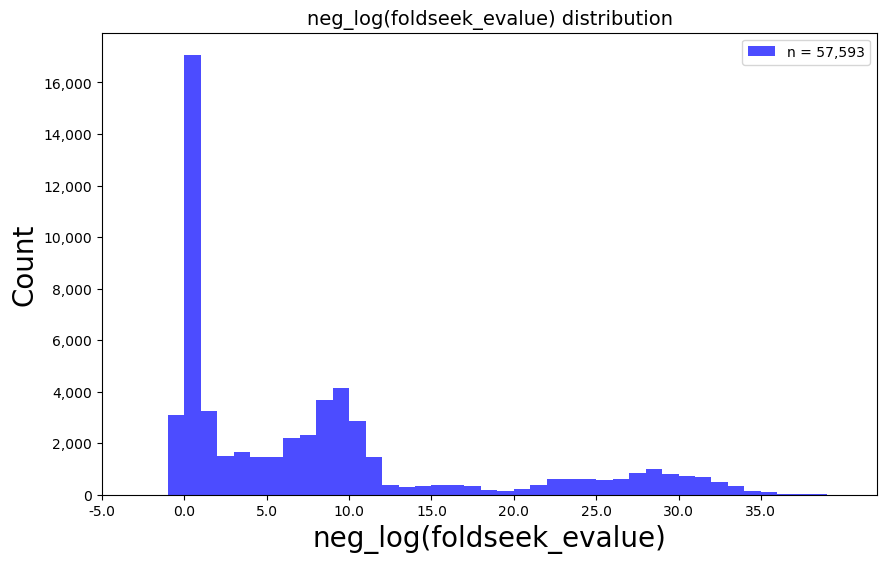

In [114]:
# ────────────────────────────────────────────────────────────
#      Plot hist: evalue_foldseek
# ────────────────────────────────────────────────────────────

# PLot histogram of `Protein_length_difference`
def out_plot(
        figure: plt.Figure,
        out_path: str,
        svg: bool = True,
        png_dpi: int = 1080
) -> None:
    out_path = Path(out_path)
    if svg:
        figure.savefig(out_path.with_suffix(".svg"))
    if png_dpi:
        figure.savefig(out_path.with_suffix(".png"), dpi=png_dpi)
    return None

def plot_hist(
        df: pl.DataFrame,
        col_name: str,
        colour: str = "blue",
        alpha: float = 0.7,
        bin_width: float = 10.0,
        tick_interval: float = 0.1,
        exclude_zeros: bool = False,
        last_bin_leftSide: float = None,
        title: str = "Var distribution",
        title_fontSize: int = 14,
        axis_label_fontSize: int = 10,
        xlabel: str = "Var",
        ylabel: str = "Count",
        threshold: float = None,
        threshold_ann: str = None,
        threshold_ann_side: str = "left",
        dims: Tuple[int, int] = (10, 6),
        out_path: str = None
) -> None:

    var = df[col_name].to_numpy().astype(float)
    min, max = var.min(), var.max()
    logger.info(f"{col_name} max: {round(max, 4):,}")
    logger.info(f"{col_name} min: {round(min, 4):,}")
    fig, ax = plt.subplots(figsize=dims)

    if exclude_zeros:
        var = var[var != 0]
        min = var.min()
        logger.info(f"Trimmed min {col_name}: {min}")
        
    if last_bin_leftSide is not None:
        var = np.where(
            var > last_bin_leftSide,
            last_bin_leftSide + bin_width,
            var
        )
        max = var.max()
        def _fmt(x, pos):
            if np.isclose(x, max - bin_width):
                return f"{int(last_bin_leftSide):,}+"
            return f"{int(x):,}"
        
        logger.info(f"Trimmed max {col_name}: {max}")
    
    else:
        def _fmt(x, pos):
            return f"{round(x, 2):,}"

    l = np.floor(min / tick_interval) * tick_interval
    u = np.ceil(max / tick_interval) * tick_interval
    xticks = np.arange(l, u, tick_interval)

    l = np.floor(min / bin_width) * bin_width
    u = np.ceil(max / bin_width) * bin_width
    edges = np.arange(l, u + bin_width, bin_width)

    ax.hist(var, bins=edges, color=colour, alpha=alpha, label=f"n = {var.size:,}")
    ax.legend()
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.xaxis.set_major_formatter(FuncFormatter(_fmt))
    ax.set_xticks(xticks)
    ax.set_xlabel(xlabel, fontsize=axis_label_fontSize)
    ax.set_ylabel(ylabel, fontsize=axis_label_fontSize)
    ax.set_title(title, fontsize=title_fontSize)

    if threshold is not None:
        ax.axvline(x=threshold, color="red", linestyle="--", linewidth=1)
        if threshold_ann is None:
            threshold_ann = f"Threshold: {threshold}"
        ax.text(threshold, ax.get_ylim()[1]*0.95, threshold_ann, color="red", ha=threshold_ann_side, va="top", fontsize=axis_label_fontSize)

    if out_path is not None:
        out_plot(figure=fig, out_path=out_path, svg=True, png_dpi=1080)

    plt.show()

plot_hist(
    df=df_ann,
    colour="blue",
    col_name=VAR_NAME_LOG_EVALUE,
    tick_interval=5,
    bin_width=1,
    title=f"{VAR_NAME_LOG_EVALUE} distribution",
    xlabel=VAR_NAME_LOG_EVALUE,
    axis_label_fontSize=20,
    out_path=f"{OUT_DIR}/hist_{VAR_NAME_LOG_EVALUE.replace(')', '').replace('(', '')}"
)

In [104]:
# ────────────────────────────────────────────────────────────
#      Filter: pair in same cluster
# ────────────────────────────────────────────────────────────

def filter_data(
        df: pl.DataFrame,
) -> pl.DataFrame:
    df = df.filter(
        (pl.col("defense_system_cluster_id") == pl.col("cluster_id")) &
        (pl.col("Organism") == "Homo sapiens (Human)")
    )
    logger.info(f"N rows after filtering: {len(df)}")
    return df

df_filt = filter_data(
    df=df_ann
)
df_filt.write_csv(
    f"{OUT_DIR}/zorya_protein_pairs_filt_n={len(df_filt)}",
    separator="\t",
    include_header=True
)
df_filt

INFO:__main__:N rows after filtering: 297


accession_in_sys,type,subtype,species,sys_id,sys_beg,sys_end,duplicate_count,rank,defense_system_protein_id,defense_system_cluster_id,cluster_id,protein_id,evalue,cluFlag,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue_foldseek,bits,Reviewed,Entry Name,Protein names,Gene Names,Organism,Gene Names (ordered locus),Gene Names (ORF),Gene Names (primary),Gene Names (synonym),Proteomes,Gene Ontology (biological process),Gene Ontology (cellular component),Gene Ontology (GO),Gene Ontology (molecular function),Gene Ontology IDs,CDD,FunFam,Gene3D,InterPro,PANTHER,Pfam,PROSITE,SMART,RefSeq,Query_range,Query_length,Human_prot_total_length,Human_prot_domain_match,Human_domain_percentage,Query_percentage,Query_overlap_w_Human_protein,Human_domain_note,Human_domain_evidence,Target_range,Target_length,Bacterial_prot_total_length,Bacterial_prot_domain_match,Bacterial_domain_percentage,Target_percentage,Target_overlap_w_Bacterial_protein,Bacterial_domain_note,Bacterial_domain_evidence,Bacterial_Human_Len_Ratio,Query_Target_Overlap_Length,Overlap_ratio,Protein_length_difference,neg_log(foldseek_evalue)
str,str,str,str,str,str,str,i64,i64,str,str,str,str,f64,i64,f64,i64,i64,f64,i64,i64,i64,i64,f64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,f64,f64,f64,str,str,str,i64,i64,str,f64,f64,f64,str,str,f64,f64,f64,f64,f64
"""WP_012123970.1""","""Zorya""","""Zorya_TypeI""","""Cronobacter sakazakii""","""GCF_018884145_NZ_CP049150_Zory…","""GCF_018884085.1_NZ_CP049147_03…","""GCF_018884085.1_NZ_CP049147_03…",3,200,"""A7MEH1""","""A0A7S4UXI5""","""A0A7S4UXI5""","""B3KX98""",0.0,2,0.212,179,133,0.0,705,874,899,1077,1.2940e-7,260,"""unreviewed""","""B3KX98_HUMAN""","""cDNA FLJ45012 fis, clone BRAWH…",null,"""Homo sapiens (Human)""",null,null,null,null,null,null,"""nucleus [GO:0005634]""","""nucleus [GO:0005634]; ATP bind…","""ATP binding [GO:0005524]; heli…","""GO:0004386; GO:0005524; GO:000…","""cd16569; RING-HC_SHPRH-like; 1…","""3.30.40.10:FF:000162; E3 ubiqu…","""3.40.50.300; P-loop containing…","""IPR052583; ATP-helicase/E3_Ub-…","""PTHR45865:SF1; E3 UBIQUITIN-PR…","""PF00271; Helicase_C; 1.;""PF213…","""PS51194; HELICASE_CTER; 1.;""PS…","""SM00490; HELICc; 1.;""SM00184; …","""NP_001036148.2; NM_001042683.2…","""705.0..874.0""",170,882,"""713..871""",100.0,93.53,19.27,"""['Helicase C-terminal']""","""['ECO:0000259|PROSITE:PS51194'…","""899.0..1077.0""",179,1080,"""904..1069""",100.0,92.74,16.57,"""['Helicase C-terminal']""","""['ECO:0000259|PROSITE:PS51194'…",1.22449,170.0,0.192744,0.22449,6.888066
"""WP_128105540.1""","""Zorya""","""Zorya_TypeI""","""Acetobacter oryzoeni""","""GCF_004014775_NZ_CP042808_Zory…","""GCF_004014775.2_NZ_CP042808_01…","""GCF_004014775.2_NZ_CP042808_01…",1,202,"""A0A5B9GHV7""","""A0A355UP19""","""A0A355UP19""","""Q9H4L7""",0.0,1,0.196,657,524,0.0,370,1026,362,1014,9.7780e-28,762,"""reviewed""","""SMRCD_HUMAN""","""SWI/SNF-related matrix-associa…","""SMARCAD1 KIAA1122""","""Homo sapiens (Human)""",null,null,"""SMARCAD1""","""KIAA1122""","""UP000005640: Chromosome 4""","""chromatin remodeling [GO:00063…","""chromatin [GO:0000785]; hetero…","""chromatin [GO:0000785]; hetero…","""ATP binding [GO:0005524]; ATP …","""GO:0000018; GO:0000729; GO:000…","""cd17998; DEXHc_SMARCAD1; 1.;""c…","""3.40.50.10810:FF:000014; SWI/S…","""3.40.50.300; P-loop containing…","""IPR003892; CUE.;""IPR014001; He…","""PTHR10799; SNF2/RAD54 HELICASE…","""PF00271; Helicase_C; 1.;""PF001…","""PS51140; CUE; 2.;""PS51192; HEL…","""SM00487; DEXDc; 1.;""SM00490; H…","""NP_001121901.1; NM_001128429.3…","""370.0..1026.0""",657,1026,"""509..677""",100.0,25.72,64.04,"""['Helicase ATP-binding']""","""['ECO:0000255|PROSITE-ProRule:…","""362.0..1014.0""",653,1028,"""505..697""",100.0,29.56,63.52,"""['Helicase ATP-binding']""","""['ECO:0000259|PROSITE:PS51192'…",1.001949,653.0,0.636452,0.001949,27.00975
"""WP_141991876.1""","""Zorya""","""Zorya_TypeI""","""Acinetobacter baumannii""","""

In [105]:
# ────────────────────────────────────────────────────────────
#      Unique protein pairs
# ────────────────────────────────────────────────────────────

def summarise_protein_matches(
    df: pl.DataFrame,
    col_bact_prot_id: str,
    col_human_prot_id: str,
    col_cluster_id: str
) -> pl.DataFrame:

    logger.info(f"N protein matches: {len(df)}")

    unique_clusters = df[col_cluster_id].unique()
    logger.info(f"N unique clusters: {len(unique_clusters)}")

    unique_protein_pairs = df.unique(
        subset=[col_bact_prot_id, col_human_prot_id, col_cluster_id]
    ).sort(col_cluster_id)

    logger.info(f"N unique protein pairs: {len(unique_protein_pairs)}")
    logger.info(unique_clusters)

    return unique_protein_pairs

df_unq_matches = summarise_protein_matches(
    df_filt,
    col_bact_prot_id=COL_BACT_PROT_ID,
    col_human_prot_id=COL_HS_PROT_ID,
    col_cluster_id=COL_CLUSTER_ID
)
df_unq_matches.write_csv(
    OUT_DIR / f"zorya_unique_protein_pairs_n={len(df_unq_matches)}.tsv",
    separator="\t",
    include_header=True
)
df_unq_matches

INFO:__main__:N protein matches: 297
INFO:__main__:N unique clusters: 2
INFO:__main__:N unique protein pairs: 76
INFO:__main__:shape: (2,)
Series: 'cluster_id' [str]
[
	"A0A7S4UXI5"
	"A0A355UP19"
]


accession_in_sys,type,subtype,species,sys_id,sys_beg,sys_end,duplicate_count,rank,defense_system_protein_id,defense_system_cluster_id,cluster_id,protein_id,evalue,cluFlag,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue_foldseek,bits,Reviewed,Entry Name,Protein names,Gene Names,Organism,Gene Names (ordered locus),Gene Names (ORF),Gene Names (primary),Gene Names (synonym),Proteomes,Gene Ontology (biological process),Gene Ontology (cellular component),Gene Ontology (GO),Gene Ontology (molecular function),Gene Ontology IDs,CDD,FunFam,Gene3D,InterPro,PANTHER,Pfam,PROSITE,SMART,RefSeq,Query_range,Query_length,Human_prot_total_length,Human_prot_domain_match,Human_domain_percentage,Query_percentage,Query_overlap_w_Human_protein,Human_domain_note,Human_domain_evidence,Target_range,Target_length,Bacterial_prot_total_length,Bacterial_prot_domain_match,Bacterial_domain_percentage,Target_percentage,Target_overlap_w_Bacterial_protein,Bacterial_domain_note,Bacterial_domain_evidence,Bacterial_Human_Len_Ratio,Query_Target_Overlap_Length,Overlap_ratio,Protein_length_difference,neg_log(foldseek_evalue)
str,str,str,str,str,str,str,i64,i64,str,str,str,str,f64,i64,f64,i64,i64,f64,i64,i64,i64,i64,f64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,f64,f64,f64,str,str,str,i64,i64,str,f64,f64,f64,str,str,f64,f64,f64,f64,f64
"""WP_014147288.1""","""Zorya""","""Zorya_TypeI""","""Methylotuvimicrobium alcaliphi…","""GCF_000968535_NC_016112_Zorya_…","""GCF_000968535.2_NC_016112_0076…","""GCF_000968535.2_NC_016112_0076…",1,202,"""G4T261""","""A0A355UP19""","""A0A355UP19""","""B4DLD8""",0.0,1,0.201,626,496,0.0,309,930,373,998,4.4990e-31,823,"""unreviewed""","""B4DLD8_HUMAN""","""DNA helicase (EC 3.6.4.12)""",null,"""Homo sapiens (Human)""",null,null,null,null,null,"""chromatin organization [GO:000…","""nucleus [GO:0005634]""","""nucleus [GO:0005634]; ATP bind…","""ATP binding [GO:0005524]; DNA …","""GO:0003677; GO:0004386; GO:000…","""cd18668; CD1_tandem_CHD5-9_lik…","""2.40.50.40:FF:000001; chromodo…","""2.40.50.40; -; 2.;""3.40.50.300…","""IPR051493; CHD.;""IPR016197; Ch…","""PTHR46850; CHROMODOMAIN-HELICA…","""PF00385; Chromo; 2.;""PF00271; …","""PS50013; CHROMO_2; 1.;""PS00690…","""SM00298; CHROMO; 2.;""SM00487; …",null,"""309.0..930.0""",622,1014,"""451..625""",100.0,28.14,61.34,"""['Helicase ATP-binding']""","""['ECO:0000259|PROSITE:PS51192'…","""373.0..998.0""",626,1003,"""832..994""",100.0,26.04,62.41,"""['Helicase C-terminal']""","""['ECO:0000259|PROSITE:PS51194'…",0.989152,622.0,0.62014,0.010848,30.346884
"""WP_013838039.1""","""Zorya""","""Zorya_TypeI""","""Isoptericola variabilis""","""GCF_000215105_NC_015588_Zorya_…","""GCF_000215105.1_NC_015588_0087…","""GCF_000215105.1_NC_015588_0088…",1,202,"""F6FPD4""","""A0A355UP19""","""A0A355UP19""","""Q9H4L7""",0.0,1,0.209,557,438,0.0,469,1025,449,1003,2.6260e-26,866,"""reviewed""","""SMRCD_HUMAN""","""SWI/SNF-related matrix-associa…","""SMARCAD1 KIAA1122""","""Homo sapiens (Human)""",null,null,"""SMARCAD1""","""KIAA1122""","""UP000005640: Chromosome 4""","""chromatin remodeling [GO:00063…","""chromatin [GO:0000785]; hetero…","""chromatin [GO:0000785]; hetero…","""ATP binding [GO:0005524]; ATP …","""GO:0000018; GO:0000729; GO:000…","""cd17998; DEXHc_SMARCAD1; 1.;""c…","""3.40.50.10810:FF:000014; SWI/S…","""3.40.50.300; P-loop containing…","""IPR003892; CUE.;""IPR014001; He…","""PTHR10799; SNF2/RAD54 HELICASE…","""PF00271; Helicase_C; 1.;""PF001…","""PS51140; CUE; 2.;""PS51192; HEL…","""SM00487; DEXDc; 1.;""SM00490; H…","""NP_001121901.1; NM_001128429.3…","""469.0..1025.0""",557,1026,"""858..1010""",100.0,27.47,54.29,"""['Helicase C-terminal']""","""['ECO:0000255|PROSITE-ProRule:…","""449.0..1003.0""",555,1005,"""835..994""",100.0,28.83,55.22,"""['Helicase C-terminal']""","""['ECO:0000259|PROSITE:PS51194'…",0.979532,555.0,0.552239,0.020468,25.580705
"""WP_174757529.1""","""Zorya""","""Zorya_TypeI""","""Azospirillum oryzae"""

INFO:__main__:Protein_length_difference max: 0.2404
INFO:__main__:Protein_length_difference min: 0.001


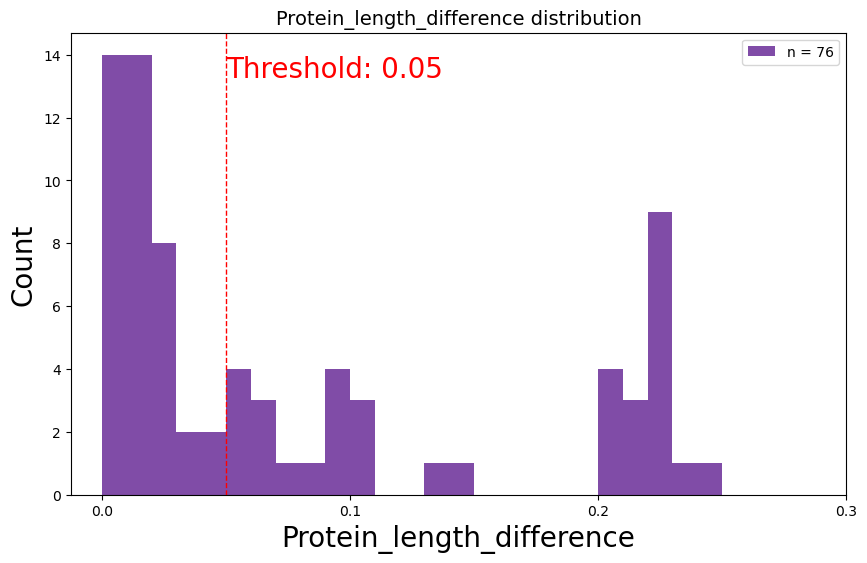

In [107]:
# ────────────────────────────────────────────────────────────
#      Plot hist: length difference
# ────────────────────────────────────────────────────────────

plot_hist(
    df=df_unq_matches,
    colour="indigo",
    col_name=VAR_NAME_LENGTH_ERROR,
    tick_interval=0.1,
    bin_width=0.01,
    title=f"{VAR_NAME_LENGTH_ERROR} distribution",
    xlabel=VAR_NAME_LENGTH_ERROR,
    out_path=f"{OUT_DIR}/hist_{VAR_NAME_LENGTH_ERROR}",
    threshold=THRESHOLD_LENGTH_ERROR,
    axis_label_fontSize=20
)

INFO:__main__:Overlap_ratio max: 0.7529
INFO:__main__:Overlap_ratio min: 0.1678


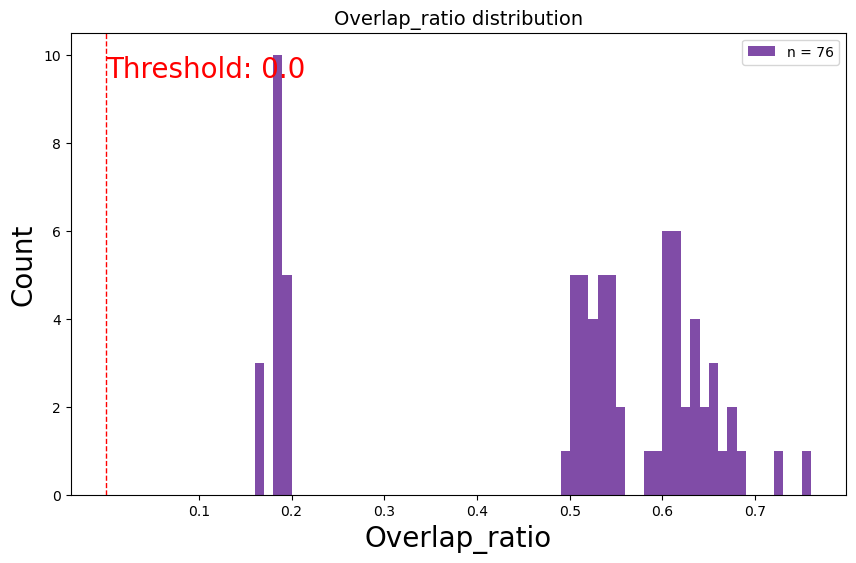

In [108]:
# ────────────────────────────────────────────────────────────
#      Plot hist: Overlap ratio
# ────────────────────────────────────────────────────────────

plot_hist(
    df=df_unq_matches,
    col_name="Overlap_ratio",
    colour="indigo",
    tick_interval=0.1,
    bin_width=0.01,
    title=f"Overlap_ratio distribution",
    xlabel="Overlap_ratio",
    axis_label_fontSize=20,
    out_path=f"{OUT_DIR}/hist_Overlap_ratio",
    threshold=THRESHOLD_OVERLAP_RATIO,
    threshold_ann_side="left"
)

In [109]:
# ────────────────────────────────────────────────────────────
#      Filter by annotations
# ────────────────────────────────────────────────────────────

def filter_extra_metrics(
        df: pl.DataFrame,
        var_length_error: str,
        threshold_length_error: float,
        threshold_overlap_ratio: float
) -> pl.DataFrame:
    
    df = df.filter(
        (pl.col(var_length_error) <= threshold_length_error) &
        (pl.col("Overlap_ratio") >= threshold_overlap_ratio)
    )

    logger.info(f"N rows after filtering by extra metrics: {len(df)}")
    return df

df_ann_filt = filter_extra_metrics(
    df=df_unq_matches,
    var_length_error=VAR_NAME_LENGTH_ERROR,
    threshold_length_error=THRESHOLD_LENGTH_ERROR,
    threshold_overlap_ratio=THRESHOLD_OVERLAP_RATIO
)

df_ann_filt.write_csv(
    f"{OUT_DIR}/zorya_unique_protein_pairs_filt_n={len(df_ann_filt)}.tsv",
    separator="\t",
    include_header=True
)

summarise_protein_matches(
    df_ann_filt,
    col_bact_prot_id=COL_BACT_PROT_ID,
    col_human_prot_id=COL_HS_PROT_ID,
    col_cluster_id=COL_CLUSTER_ID
)

INFO:__main__:N rows after filtering by extra metrics: 40
INFO:__main__:N protein matches: 40
INFO:__main__:N unique clusters: 1
INFO:__main__:N unique protein pairs: 40
INFO:__main__:shape: (1,)
Series: 'cluster_id' [str]
[
	"A0A355UP19"
]


accession_in_sys,type,subtype,species,sys_id,sys_beg,sys_end,duplicate_count,rank,defense_system_protein_id,defense_system_cluster_id,cluster_id,protein_id,evalue,cluFlag,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue_foldseek,bits,Reviewed,Entry Name,Protein names,Gene Names,Organism,Gene Names (ordered locus),Gene Names (ORF),Gene Names (primary),Gene Names (synonym),Proteomes,Gene Ontology (biological process),Gene Ontology (cellular component),Gene Ontology (GO),Gene Ontology (molecular function),Gene Ontology IDs,CDD,FunFam,Gene3D,InterPro,PANTHER,Pfam,PROSITE,SMART,RefSeq,Query_range,Query_length,Human_prot_total_length,Human_prot_domain_match,Human_domain_percentage,Query_percentage,Query_overlap_w_Human_protein,Human_domain_note,Human_domain_evidence,Target_range,Target_length,Bacterial_prot_total_length,Bacterial_prot_domain_match,Bacterial_domain_percentage,Target_percentage,Target_overlap_w_Bacterial_protein,Bacterial_domain_note,Bacterial_domain_evidence,Bacterial_Human_Len_Ratio,Query_Target_Overlap_Length,Overlap_ratio,Protein_length_difference,neg_log(foldseek_evalue)
str,str,str,str,str,str,str,i64,i64,str,str,str,str,f64,i64,f64,i64,i64,f64,i64,i64,i64,i64,f64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,f64,f64,f64,str,str,str,i64,i64,str,f64,f64,f64,str,str,f64,f64,f64,f64,f64
"""WP_109992022.1""","""Zorya""","""Zorya_TypeI""","""Salinisphaera sp. LB1""","""GCF_003177035_NZ_CP029488_Zory…","""GCF_003177035.1_NZ_CP029488_00…","""GCF_003177035.1_NZ_CP029488_00…",1,202,"""A0A2Z3J444""","""A0A355UP19""","""A0A355UP19""","""B4DLD8""",0.0,1,0.213,631,459,0.0,307,937,404,987,2.6750e-33,923,"""unreviewed""","""B4DLD8_HUMAN""","""DNA helicase (EC 3.6.4.12)""",null,"""Homo sapiens (Human)""",null,null,null,null,null,"""chromatin organization [GO:000…","""nucleus [GO:0005634]""","""nucleus [GO:0005634]; ATP bind…","""ATP binding [GO:0005524]; DNA …","""GO:0003677; GO:0004386; GO:000…","""cd18668; CD1_tandem_CHD5-9_lik…","""2.40.50.40:FF:000001; chromodo…","""2.40.50.40; -; 2.;""3.40.50.300…","""IPR051493; CHD.;""IPR016197; Ch…","""PTHR46850; CHROMODOMAIN-HELICA…","""PF00385; Chromo; 2.;""PF00271; …","""PS50013; CHROMO_2; 1.;""PS00690…","""SM00298; CHROMO; 2.;""SM00487; …",null,"""307.0..937.0""",631,1014,"""451..625""",100.0,27.73,62.23,"""['Helicase ATP-binding']""","""['ECO:0000259|PROSITE:PS51192'…","""404.0..987.0""",584,989,"""815..984""",100.0,29.11,59.05,"""['Helicase C-terminal']""","""['ECO:0000259|PROSITE:PS51194'…",0.975345,584.0,0.590495,0.024655,32.572676
"""WP_099775859.1""","""Zorya""","""Zorya_TypeI""","""Pseudomonas sp. HLS-6""","""GCF_002753995_NZ_CP024478_Zory…","""GCF_002753995.1_NZ_CP024478_04…","""GCF_002753995.1_NZ_CP024478_04…",1,202,"""A0A2D2MBG9""","""A0A355UP19""","""A0A355UP19""","""Q9H4L7""",0.0,1,0.207,586,444,0.0,466,1026,427,1012,2.3000e-27,877,"""reviewed""","""SMRCD_HUMAN""","""SWI/SNF-related matrix-associa…","""SMARCAD1 KIAA1122""","""Homo sapiens (Human)""",null,null,"""SMARCAD1""","""KIAA1122""","""UP000005640: Chromosome 4""","""chromatin remodeling [GO:00063…","""chromatin [GO:0000785]; hetero…","""chromatin [GO:0000785]; hetero…","""ATP binding [GO:0005524]; ATP …","""GO:0000018; GO:0000729; GO:000…","""cd17998; DEXHc_SMARCAD1; 1.;""c…","""3.40.50.10810:FF:000014; SWI/S…","""3.40.50.300; P-loop containing…","""IPR003892; CUE.;""IPR014001; He…","""PTHR10799; SNF2/RAD54 HELICASE…","""PF00271; Helicase_C; 1.;""PF001…","""PS51140; CUE; 2.;""PS51192; HEL…","""SM00487; DEXDc; 1.;""SM00490; H…","""NP_001121901.1; NM_001128429.3…","""466.0..1026.0""",561,1026,"""509..677""",100.0,30.12,54.68,"""['Helicase ATP-binding']""","""['ECO:0000255|PROSITE-ProRule:…","""427.0..1012.0""",586,1012,"""479..687""",100.0,35.67,57.91,"""['Helicase ATP-binding']""","""['ECO:0000259|PROSITE:PS51192'…",0.986355,561.0,0.554348,0.013645,26.638272
"""WP_151184585.1""","""Zorya""","""Zorya_TypeI""","""Pseudomonas sp. C27(201

In [85]:
# ──── Scrap ─────────────────────────────────────────────────

tmp = (
    df
    .group_by(["protein_id", "defense_system_protein_id"])
    .len()
    .sort("len", descending=True)
)
tmp.filter(pl.col("len") == 4)

protein_id,defense_system_protein_id,len
str,str,u32
"""A0A126LB10""","""A0A1I7JXK9""",4
"""A0A384N605""","""Q2SG57""",4
"""J3QL43""","""A0A0K2GFK9""",4
"""J3QL43""","""G7LQI9""",4
"""F8VRX4""","""A0A7S7ADN0""",4
…,…,…
"""Q15HH2""","""B4XH94""",4
"""Q5XTD1""","""B4XH94""",4
"""Q6RMK4""","""B4XH94""",4


In [87]:
# ──── Scrap ─────────────────────────────────────────────────

tmp = df.filter(
    (pl.col(COL_HS_PROT_ID) == "A0A126LB10") &
    (pl.col(COL_BACT_PROT_ID) == "A0A1I7JXK9")
)
tmp

accession_in_sys,type,subtype,species,sys_id,sys_beg,sys_end,duplicate_count,rank,defense_system_protein_id,defense_system_cluster_id,cluster_id,protein_id,evalue,cluFlag,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue_foldseek,bits,Reviewed,Entry Name,Protein names,Gene Names,Organism,Gene Names (ordered locus),Gene Names (ORF),Gene Names (primary),Gene Names (synonym),Proteomes,Gene Ontology (biological process),Gene Ontology (cellular component),Gene Ontology (GO),Gene Ontology (molecular function),Gene Ontology IDs,CDD,FunFam,Gene3D,InterPro,PANTHER,Pfam,PROSITE,SMART,RefSeq,Query_range,Query_length,Human_prot_total_length,Human_prot_domain_match,Human_domain_percentage,Query_percentage,Query_overlap_w_Human_protein,Human_domain_note,Human_domain_evidence,Target_range,Target_length,Bacterial_prot_total_length,Bacterial_prot_domain_match,Bacterial_domain_percentage,Target_percentage,Target_overlap_w_Bacterial_protein,Bacterial_domain_note,Bacterial_domain_evidence,Bacterial_Human_Len_Ratio,Query_Target_Overlap_Length,Overlap_ratio
str,str,str,str,str,str,str,i64,i64,str,str,str,str,f64,i64,f64,i64,i64,f64,i64,i64,i64,i64,f64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,f64,f64,f64,str,str,str,i64,i64,str,f64,f64,f64,str,str,f64,f64,f64
"""WP_068836923.1""","""Zorya""","""Zorya_TypeI""","""Pontibacter akesuensis""","""GCF_001611675_NZ_CP014766_Zory…","""GCF_001611675.1_NZ_CP014766_00…","""GCF_001611675.1_NZ_CP014766_00…",1,202,"""A0A1I7JXK9""","""A0A101WRB2""","""A0A3M2G291""","""A0A126LB10""",0.9081,2,0.106,494,397,0.0,61,554,629,1073,0.001074,38,"""unreviewed""","""A0A126LB10_HUMAN""","""U60/66""","""66 U60""","""Homo sapiens (Human)""",null,null,"""66""","""U60""",null,"""chromosome organization [GO:00…",null,"""DNA binding [GO:0003677]; hydr…","""DNA binding [GO:0003677]; hydr…","""GO:0003677; GO:0016787; GO:005…",null,null,"""3.30.420.320; -; 1.;""3.40.50.3…","""IPR003498; DNA_pack_C.;""IPR038…",null,"""PF02499; DNA_pack_C; 1.;""PF025…",null,null,null,"""61.0..554.0""",494,666,"""45..295""",93.63,47.57,74.17,"""['Probable DNA packing protein…","""['ECO:0000259|Pfam:PF02500']""","""629.0..1073.0""",445,1088,"""752..920""",100.0,37.98,40.9,"""['Helicase C-terminal']""","""['ECO:0000259|PROSITE:PS51194'…",1.633634,445.0,0.668168
"""WP_068836923.1""","""Zorya""","""Zorya_TypeI""","""Pontibacter akesuensis""","""GCF_001611675_NZ_CP014766_Zory…","""GCF_001611675.1_NZ_CP014766_00…","""GCF_001611675.1_NZ_CP014766_00…",1,202,"""A0A1I7JXK9""","""A0A101WRB2""","""A0A3M2G291""","""A0A126LB10""",0.9081,2,0.106,494,397,0.0,61,554,629,1073,0.001074,38,"""unreviewed""","""A0A126LB10_HUMAN""","""U60/66""","""66 U60""","""Homo sapiens (Human)""",null,null,"""66""","""U60""",null,"""chromosome organization [GO:00…",null,"""DNA binding [GO:0003677]; hydr…","""DNA binding [GO:0003677]; hydr…","""GO:0003677; GO:0016787; GO:005…",null,null,"""3.30.420.320; -; 1.;""3.40.50.3…","""IPR003498; DNA_pack_C.;""IPR038…",null,"""PF02499; DNA_pack_C; 1.;""PF025…",null,null,null,"""61.0..554.0""",494,666,"""45..295""",93.63,47.57,74.17,"""['Probable DNA packing protein…","""['ECO:0000259|Pfam:PF02500']""","""629.0..1073.0""",445,1088,"""752..920""",100.0,37.98,40.9,"""['Helicase C-terminal']""","""['ECO:0000259|PROSITE:PS51194'…",1.633634,445.0,0.668168
"""WP_068836923.1""","""Zorya""","""Zorya_TypeI""","""Pontibacter akesuensis""","""GCF_001611675_NZ_CP014766_Zory…","""GCF_001611675.1_NZ_CP014766_00…","""GCF_001611675.1_NZ_CP014766_00…",1,202,"""A0A1I7JXK9""","""A0A101WRB2""","""A0A3M2G291""","""A0A126LB10""",0.9081,2,0.106,494,397,0.0,61,554,629,1073,0.001074,38,"""unreviewed""","""A0A126LB10_HUMAN""","""U60/66""","""66 U60""","""Homo sapiens (Human)""",null,null,"""66""","""U60""",null,"""chromosome organization [GO:00…",null,"""DNA binding [GO:0003677]; hydr…","""DNA binding [GO:0003677]; hydr…","""GO:0003677; GO:0016787; GO:005…",null,null,"""3.30.420.320; -; 1.;""

In [ ]:
# ────────────────────────────────────────────────────────────
#      Plot hist: foldseek evalue
# ────────────────────────────────────────────────────────────

In [ ]:
# ────────────────────────────────────────────────────────────
#      Plot scatter: evalues
# ────────────────────────────────────────────────────────────

In [32]:
type(VAR_NAME_LENGTH_ERROR)

str